# Infleqtion's Sqale atom rearrangement demo 

One of the biggest features that distinguishes neutral atom systems, such as Infleqtion's Sqale QPU, is the functionality of atom rearrangement. This capability allows dynamic reconfigurability of the device's qubits to accomodate a particular connectivity between them and enable certain quantum circuit operations more easily. In particular, at the hardware-level, optical tweezers are used to achieve this, along with a spatial light modulator (SLM) for generation of a static optical tweezer array. This was leveraged in Infleqtion's recent logical qubit experiments, and in this tutorial, we will use the atom picture API through `superstaq` to demo the atom rearrangement feature on Sqale by representing a user-defined bitmap. 


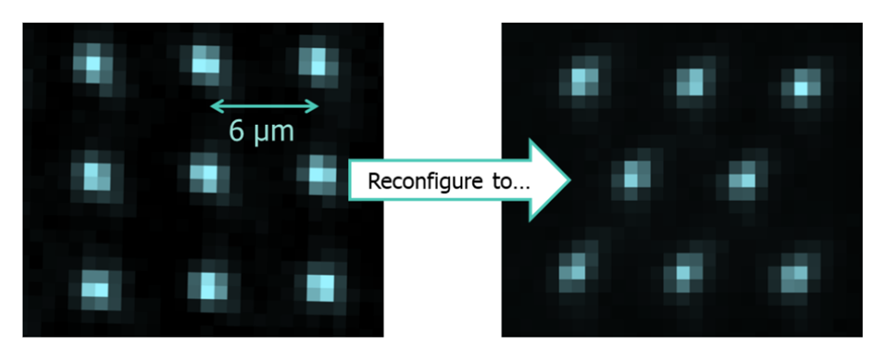

For this tutorial, you will need to import the following packages:

In [1]:
from __future__ import annotations

try:
    import general_superstaq as gss
    import numpy as np
    from PIL import Image
except ImportError:
    print("Installing required packages...")
    %pip install -r requirements.txt
    print("You may need to restart the kernel to import newly installed packages.")
    import general_superstaq as gss
    import numpy as np
    from PIL import Image

from typing import TYPE_CHECKING

if TYPE_CHECKING:
    import numpy.typing as npt

Infleqtion's atom picture API accepts a square 2D array representing a desired image. Here, we will use python's `PIL` to generate a bitmap for the atoms. The mapping is as follows: '0' indicates lack of an atom. '1' indicates the presence of an atom (and '2' could represent some random atom occupancy). As an example, we will use the atom picture API to dynamically rearrange Sqale's atoms into a heart-like shape:

In [2]:
# Load an image of your choice
image_path = "heart_logo.png"
image = Image.open(image_path)

# Resize to an API supported size
image = image.resize((7, 7))

# Convert to grayscale
image = image.convert("L")

threshold = 180  # Adjust if needed to acheive sufficient binary encoding
bitmap_array = 1 - (np.array(image) // threshold)

print(bitmap_array)

[[0 1 1 0 1 1 0]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [0 1 1 1 1 1 0]
 [0 0 1 1 1 0 0]
 [0 0 0 1 0 0 0]]


Optionally, you can use the `ascii_preview()` helper function to view `bitmap_array` more pictorally before submission

In [3]:
def ascii_preview(arr: npt.NDArray) -> str:
    choices = sorted(np.unique(arr).tolist())
    choice_map = {choices[i]: " .#"[i] for i in range(len(choices))}
    rows = [" ".join(choice_map[v] for v in row) for row in arr]
    return "\n".join(rows)

In [4]:
print(ascii_preview(bitmap_array))

  . .   . .  
. . . . . . .
. . . . . . .
. . . . . . .
  . . . . .  
    . . .    
      .      


Finally, we need to instantiate a `superstaq` service to connect with an API key to Sqale. If you do not have your Superstaq API key yet, you can make an account at https://superstaq.infleqtion.com/ and copy your API key from the landing page after login.

In [5]:
api_key = "your_api_key"
superstaq_service = gss.Service(api_key=api_key)

In [6]:
# Pass your bitmap array to the `submit_atom_picture` endpoint:
request_id = superstaq_service.submit_atom_picture(bitmap_array)

In [7]:
print(request_id)

If your submission request was successful, you should have a reference `request_id` with your Sqale job request. Next steps would be to wait for the atom picture results to be sent to the email associated with your Superstaq account. (It could take from a few minutes to a few hours or even a few days depending on Sqale's queue and availability). At the end, you would be able to get an image like:


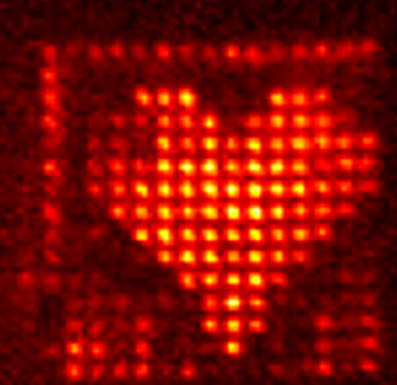
